In [1]:
import sys
sys.path.append('..')

import torch
import numpy as np
import matplotlib.pyplot as plt
from src.data.dataset import HAM10000Dataset
from src.data.augmentations import get_train_transforms, get_valid_transforms

# Load dataset
dataset = HAM10000Dataset(
    metadata_path='../data/metadata.csv',
    data_dir='../data/processed',
    split='train',
    transform=get_train_transforms(image_size=224)
)

print(f"Loaded {len(dataset)} samples")

/Users/nikhilmourya/Desktop/dermavision/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Loaded 8012 train samples

📊 Class distribution (train):
   nv     (Melanocytic Nevi         ): 5364 (66.95%)
   mel    (Melanoma                 ):  890 (11.11%)
   bkl    (Benign Keratosis         ):  879 (10.97%)
   bcc    (Basal Cell Carcinoma     ):  411 ( 5.13%)
   akiec  (Actinic Keratoses        ):  262 ( 3.27%)
   vasc   (Vascular Lesions         ):  114 ( 1.42%)
   df     (Dermatofibroma           ):   92 ( 1.15%)
Loaded 8012 samples


/Users/nikhilmourya/Desktop/dermavision/venv/lib/python3.12/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/Users/nikhilmourya/Desktop/dermavision/notebooks/../src/data/augmentations.py:31: UserWarning: Argument(s) 'value' are not valid for transform ShiftScaleRotate
  A.ShiftScaleRotate(
/Users/nikhilmourya/Desktop/dermavision/notebooks/../src/data/augmentations.py:54: UserWarning: Argument(s) 'max_holes, max_height, max_width, min_holes, min_height, min_width, fill_value' are not valid for transform CoarseDropout
  A.CoarseDropout(


✅ Loaded 8012 train samples

📊 Class distribution (train):
   nv     (Melanocytic Nevi         ): 5364 (66.95%)
   mel    (Melanoma                 ):  890 (11.11%)
   bkl    (Benign Keratosis         ):  879 (10.97%)
   bcc    (Basal Cell Carcinoma     ):  411 ( 5.13%)
   akiec  (Actinic Keratoses        ):  262 ( 3.27%)
   vasc   (Vascular Lesions         ):  114 ( 1.42%)
   df     (Dermatofibroma           ):   92 ( 1.15%)


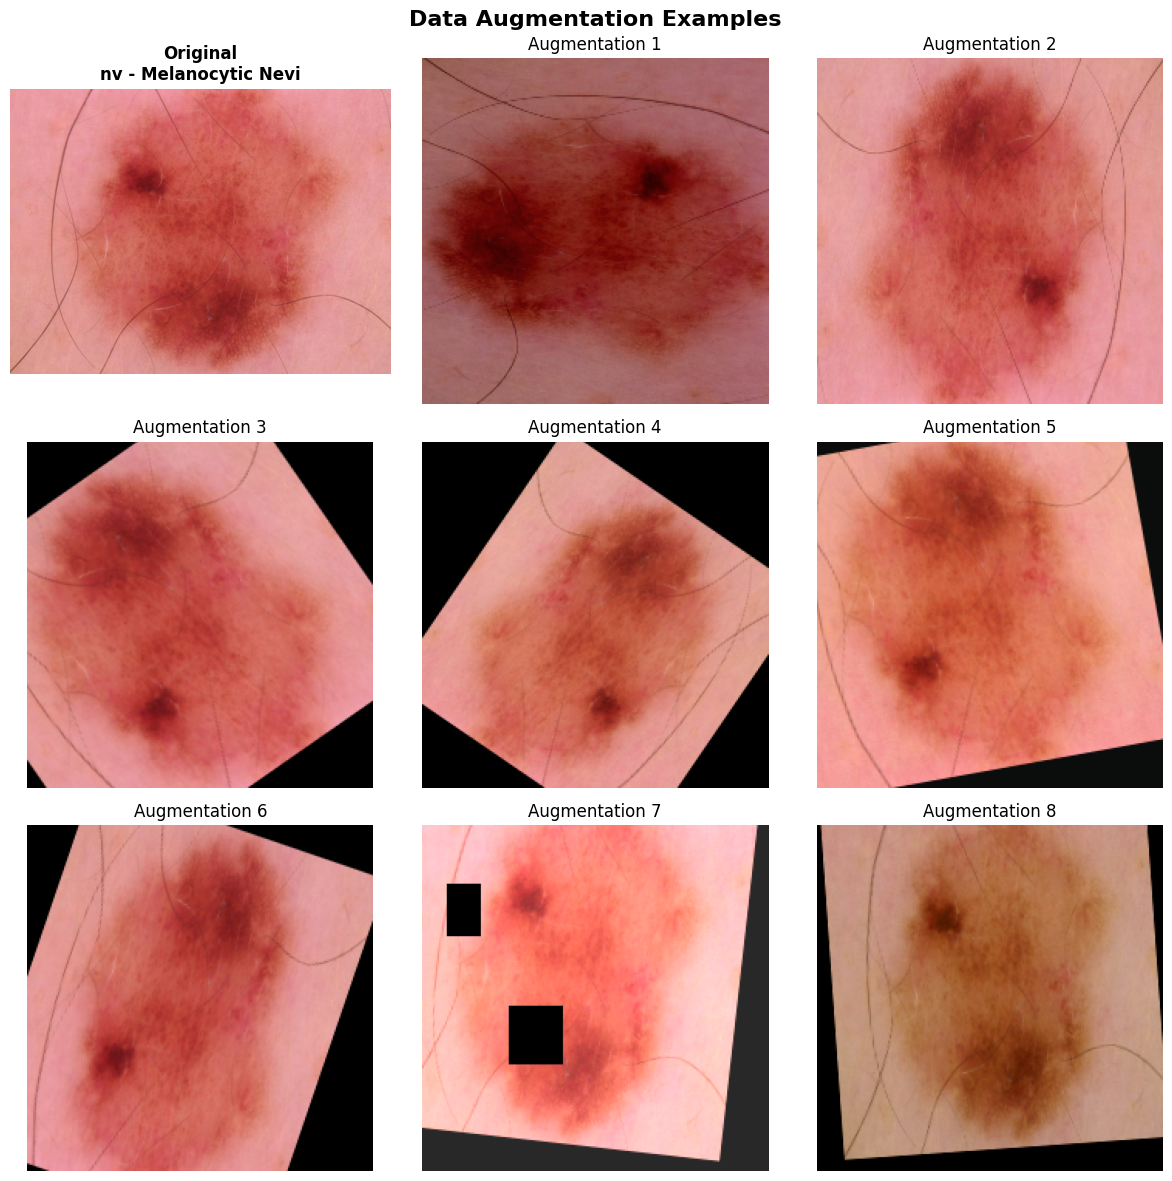

In [2]:
# Pick a sample
sample_idx = 42  # Change this to try different images

# Get original image (no transform)
dataset_no_transform = HAM10000Dataset(
    metadata_path='../data/metadata.csv',
    data_dir='../data/processed',
    split='train',
    transform=None
)

original = dataset_no_transform[sample_idx]
label = dataset.IDX_TO_CLASS[original['label']]
full_name = dataset.FULL_NAMES[label]

# Generate 8 augmented versions
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
axes = axes.flatten()

# Show original
axes[0].imshow(original['image'].permute(1, 2, 0))
axes[0].set_title(f'Original\n{label} - {full_name}', fontweight='bold')
axes[0].axis('off')

# Show augmented versions
for i in range(1, 9):
    sample = dataset[sample_idx]
    
    # Denormalize for visualization
    img = sample['image'].clone()
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img = img * std + mean
    img = torch.clamp(img, 0, 1)
    
    axes[i].imshow(img.permute(1, 2, 0))
    axes[i].set_title(f'Augmentation {i}')
    axes[i].axis('off')

plt.suptitle('Data Augmentation Examples', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()